<a href="https://colab.research.google.com/github/sabithakrishnan/timeseries-analysis/blob/main/timeseries_analysis_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_602/2455719751.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_602/2455719751.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)
/tmp/ipykernel_602/2455719751.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CO(GT)'] = df['CO(GT)'].ffill().astype

--- Performance Results ---
MAE               : 0.5432
RMSE              : 0.5281
R² Score          : 0.3809
Adjusted R² Score : 0.3793


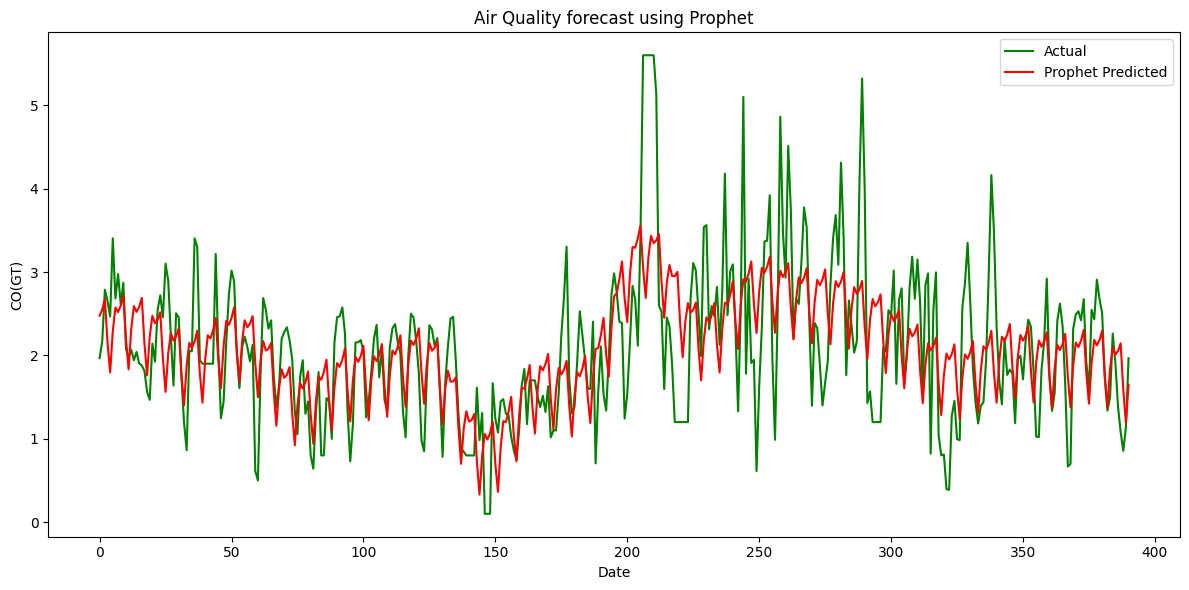

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
# 1. Load and Preprocess the UCI Air Quality Dataset
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';', decimal=',', parse_dates=[['Date', 'Time']], dayfirst=True)

# Clean dataset structure
df.dropna(how='all', inplace=True)
df = df.iloc[:, :15]

# Convert and index datetime
df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d/%m/%Y %H.%M.%S', errors='coerce')
df.dropna(subset=['Date_Time'], inplace=True)

# Replace missing values (-200) and forward fill
df.replace(-200, pd.NA, inplace=True)
df['CO(GT)'] = df['CO(GT)'].ffill().astype(float)

# Resample to daily frequency to mimic the data density in the target graph
daily_df = df.set_index('Date_Time').resample('D').mean().ffill().reset_index()

# Prophet requires a dataframe with columns explicitly named 'ds' and 'y'
prophet_df = daily_df[['Date_Time', 'CO(GT)']].rename(columns={'Date_Time': 'ds', 'CO(GT)': 'y'})

# 2. Fit the Prophet Model
# Prophet handles daily data well and automatically extracts weekly and yearly patterns
model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(prophet_df)
#Forecasting
forecast = model.predict(prophet_df)
#Accuracy metrics
y_true = prophet_df['y'].values
y_pred = forecast["yhat"].values

# MAE, RMSE, and R2
mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# Adjusted R2
n = len(y_true)     # Number of data points
p = 1               # Number of predictors (Prophet inherently uses time as 1 baseline regressor)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print(f"--- Performance Results ---")
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")
print(f"R² Score          : {r2:.4f}")
print(f"Adjusted R² Score : {adjusted_r2:.4f}")
# 4. Generate the Chart to Match Your Image Style
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(prophet_df['y'], label='Actual', color='green',linewidth=1.5)
plt.plot(forecast['yhat'], label='Prophet Predicted', color='red',linewidth=1.5)
plt.title('Air Quality forecast using Prophet', fontsize=12)
plt.xlabel('Date', fontsize=10)
plt.ylabel('CO(GT)', fontsize=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
